In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.interpolate import griddata

## Validate the combined data limit the # of files = 3 / 60

In [2]:
## Validate the combined data
# Load the combined data
raw_data_path = Path.cwd().parent / "data" / "raw" / "raw.parquet"
processed_data_path = Path.cwd().parent / "data" / "processed" / "processed.parquet"

raw = pd.read_parquet(raw_data_path)
processed = pd.read_parquet(processed_data_path)

print("Raw data shape:", raw.shape)
print("Processed data shape:", processed.shape)

Raw data shape: (9380727, 34)
Processed data shape: (15409923, 26)


In [3]:
# data columns
print("Raw data columns:")
print(raw.columns.tolist())
print("\nProcessed data columns:")
print(processed.columns.tolist())

Raw data columns:
['QUOTE_UNIXTIME', 'QUOTE_READTIME', 'QUOTE_DATE', 'QUOTE_TIME_HOURS', 'UNDERLYING_LAST', 'EXPIRE_DATE', 'EXPIRE_UNIX', 'DTE', 'C_DELTA', 'C_GAMMA', 'C_VEGA', 'C_THETA', 'C_RHO', 'C_IV', 'C_VOLUME', 'C_LAST', 'C_SIZE', 'C_BID', 'C_ASK', 'STRIKE', 'P_BID', 'P_ASK', 'P_SIZE', 'P_LAST', 'P_DELTA', 'P_GAMMA', 'P_VEGA', 'P_THETA', 'P_RHO', 'P_IV', 'P_VOLUME', 'STRIKE_DISTANCE', 'STRIKE_DISTANCE_PCT', 'source_file']

Processed data columns:
['quote_date', 'expire_date', 'underlying_last', 'strike', 'dte', 'source_file', 'bid', 'ask', 'last', 'volume', 'iv', 'delta', 'gamma', 'vega', 'option_type', 'mid', 'spread', 'rel_spread', 'tau', 'moneyness', 'k', 'abs_k', 'total_variance', 'liq_weight', 'vega_weight', 'smooth_weight']


In [4]:
# option types check
processed["option_type"].value_counts()

option_type
put     7848582
call    7561341
Name: count, dtype: int64

In [5]:
processed.describe()

,quote_date,expire_date,underlying_last,strike,dte,bid,ask,last,volume,iv,...,spread,rel_spread,tau,moneyness,k,abs_k,total_variance,liq_weight,vega_weight,smooth_weight
count,15409923,15409923,1.540992e+07,1.540992e+07,1.540992e+07,1.540992e+07,1.540992e+07,1.540992e+07,1.091775e+07,1.540992e+07,...,1.540992e+07,1.540992e+07,1.540992e+07,1.540992e+07,1.540992e+07,1.540992e+07,1.540992e+07,1.539659e+07,1.540868e+07,1.539535e+07
mean,2021-09-02 07:35:36.933999,2022-01-01 21:14:32.125036,3.841896e+03,3.544089e+03,1.215690e+02,2.176761e+02,2.221284e+02,9.865539e+01,5.204101e+01,2.964374e-01,...,4.452314e+00,1.853853e-01,3.330657e-01,9.227587e-01,-1.125891e-01,1.749922e-01,2.840536e-02,6.528358e+01,3.976844e+00,3.128474e+02
min,2019-01-02 00:00:00,2019-01-04 00:00:00,2.235760e+03,1.000000e+02,1.000000e+00,0.000000e+00,4.000000e-02,0.000000e+00,0.000000e+00,1.008000e-02,...,0.000000e+00,0.000000e+00,2.739726e-03,2.085258e-02,-3.870278e+00,0.000000e+00,3.448997e-07,5.000000e-01,1.000000e-05,3.850000e-04
25%,2020-07-16 00:00:00,2020-10-30 00:00:00,3.295440e+03,2.895000e+03,2.000000e+01,6.700000e+00,7.300000e+00,0.000000e+00,1.000000e+00,1.752900e-01,...,3.000000e-01,1.133100e-02,5.479452e-02,8.368666e-01,-1.780906e-01,3.925661e-02,2.702707e-03,1.478125e+01,7.386700e-01,1.790891e+01
50%,2021-10-06 00:00:00,2022-01-26 00:00:00,3.978390e+03,3.610000e+03,5.100000e+01,7.000000e+01,7.229000e+01,9.330000e+00,4.000000e+00,2.382100e-01,...,1.000000e+00,2.304849e-02,1.397260e-01,9.464389e-01,-5.504882e-02,9.601374e-02,9.303442e-03,4.331818e+01,2.608660e+00,1.174585e+02
75%,2022-10-28 00:00:00,2023-02-28 00:00:00,4.364850e+03,4.190000e+03,1.450000e+02,2.814000e+02,2.882000e+02,9.879000e+01,2.300000e+01,3.252000e-01,...,4.600000e+00,6.755024e-02,3.972603e-01,1.022243e+00,2.199913e-02,2.116685e-01,2.818368e-02,8.810000e+01,5.669552e+00,3.886894e+02
max,2023-12-29 00:00:00,2029-12-21 00:00:00,4.795570e+03,1.200000e+04,2.199000e+03,4.378200e+03,5.694000e+03,4.427000e+03,8.329900e+04,3.000000e+00,...,5.671000e+03,2.000000e+00,6.024658e+00,3.172044e+00,1.154376e+00,3.870278e+00,7.735679e+00,2.749875e+03,4.263707e+01,3.994277e+04
std,NaN,NaN,6.190342e+02,9.726802e+02,1.911954e+02,3.445781e+02,3.498968e+02,2.136934e+02,2.348929e+02,2.386220e-01,...,1.373954e+01,4.731201e-01,5.238231e-01,2.023217e-01,2.871778e-01,2.540179e-01,6.822049e-02,7.955316e+01,4.408841e+00,4.920508e+02


In [6]:
processed.isna().sum().sort_values(ascending=False).head(10)

volume            4492177
smooth_weight       14570
liq_weight          13331
vega_weight          1239
option_type             0
total_variance          0
abs_k                   0
k                       0
moneyness               0
tau                     0
dtype: int64

In [7]:
processed.head()

,quote_date,expire_date,underlying_last,strike,dte,source_file,bid,ask,last,volume,...,spread,rel_spread,tau,moneyness,k,abs_k,total_variance,liq_weight,vega_weight,smooth_weight
0,2019-01-02,2019-01-04,2509.98,2000.0,2.0,spx_eod_201901.txt,507.60,512.90,489.81,7.0,...,5.30,0.010387,0.005479,0.796819,-0.227128,0.227128,0.005016,96.273585,0.02672,2.572430
1,2019-01-02,2019-01-04,2509.98,2015.0,2.0,spx_eod_201901.txt,493.10,498.09,0.00,NaN,...,4.99,0.010069,0.005479,0.802795,-0.219656,0.219656,0.005728,99.317635,0.04855,4.821871
2,2019-01-02,2019-01-04,2509.98,2045.0,2.0,spx_eod_201901.txt,462.61,468.01,0.00,NaN,...,5.40,0.011605,0.005479,0.814748,-0.204877,0.204877,0.004327,86.168519,0.03215,2.770318
3,2019-01-02,2019-01-04,2509.98,2110.0,2.0,spx_eod_201901.txt,392.00,408.10,0.00,NaN,...,16.10,0.040245,0.005479,0.840644,-0.173587,0.173587,0.002350,24.847826,0.01141,0.283514
4,2019-01-02,2019-01-04,2509.98,2115.0,2.0,spx_eod_201901.txt,387.19,403.10,0.00,NaN,...,15.91,0.040264,0.005479,0.842636,-0.171220,0.171220,0.002728,24.836266,0.02351,0.583901


In [8]:
processed["quote_date"].min(), processed["quote_date"].max()

(Timestamp('2019-01-02 00:00:00'), Timestamp('2023-12-29 00:00:00'))

In [9]:
processed["quote_date"].unique()

<DatetimeArray>
['2019-01-02 00:00:00', '2019-01-03 00:00:00', '2019-01-04 00:00:00',
 '2019-01-07 00:00:00', '2019-01-08 00:00:00', '2019-01-09 00:00:00',
 '2019-01-10 00:00:00', '2019-01-11 00:00:00', '2019-01-14 00:00:00',
 '2019-01-15 00:00:00',
 ...
 '2023-12-15 00:00:00', '2023-12-18 00:00:00', '2023-12-19 00:00:00',
 '2023-12-20 00:00:00', '2023-12-21 00:00:00', '2023-12-22 00:00:00',
 '2023-12-26 00:00:00', '2023-12-27 00:00:00', '2023-12-28 00:00:00',
 '2023-12-29 00:00:00']
Length: 1248, dtype: datetime64[us]

<Axes: >

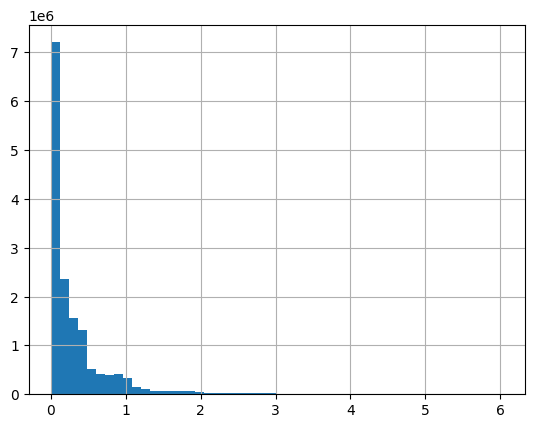

In [10]:
processed["tau"].hist(bins=50)

In [11]:
processed["tau"].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    1.540992e+07
mean     3.330657e-01
std      5.238231e-01
min      2.739726e-03
1%       2.739726e-03
5%       1.095890e-02
10%      2.191781e-02
25%      5.479452e-02
50%      1.397260e-01
75%      3.972603e-01
90%      8.684932e-01
95%      1.172603e+00
99%      2.696000e+00
max      6.024658e+00
Name: tau, dtype: float64

<Axes: >

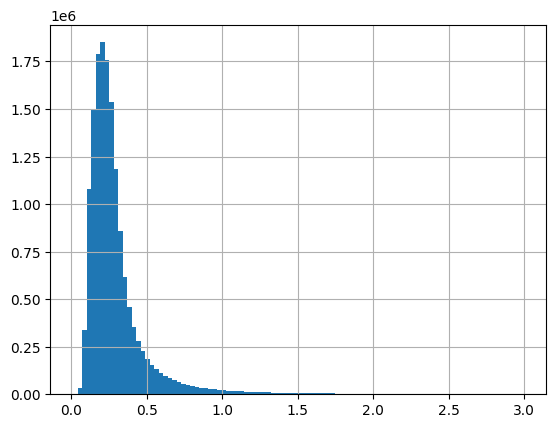

In [12]:
processed["iv"].hist(bins=100)

In [13]:
processed["iv"].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    1.540992e+07
mean     2.964374e-01
std      2.386220e-01
min      1.008000e-02
1%       8.801000e-02
5%       1.126800e-01
10%      1.317200e-01
25%      1.752900e-01
50%      2.382100e-01
75%      3.252000e-01
90%      4.910300e-01
95%      6.783500e-01
99%      1.363330e+00
max      3.000000e+00
Name: iv, dtype: float64

count    1.540992e+07
mean    -1.125891e-01
std      2.871778e-01
min     -3.870278e+00
1%      -1.235026e+00
5%      -5.841655e-01
10%     -3.697617e-01
25%     -1.780906e-01
50%     -5.504882e-02
75%      2.199913e-02
90%      1.008676e-01
95%      1.827123e-01
99%      3.864919e-01
max      1.154376e+00
Name: k, dtype: float64

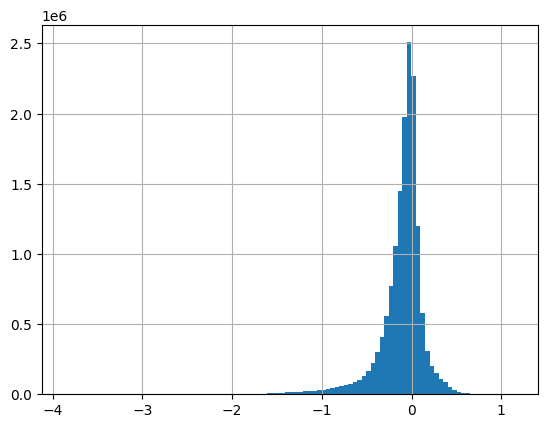

In [14]:
processed["k"].hist(bins=100)
processed["k"].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

In [15]:
processed["rel_spread"] = np.where(processed["mid"] > 0, processed["spread"] / processed["mid"], np.nan)
processed["rel_spread"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    1.540992e+07
mean     1.853853e-01
std      4.731201e-01
min      0.000000e+00
50%      2.304849e-02
75%      6.755024e-02
90%      4.000000e-01
95%      2.000000e+00
99%      2.000000e+00
max      2.000000e+00
Name: rel_spread, dtype: float64

In [16]:
sample_date = processed["quote_date"].dropna().sort_values().iloc[0]
sample_date

day = processed.loc[processed["quote_date"] == sample_date].copy()
print(day.shape)
day.head()

tau_target = day["tau"].median()
subset = day.iloc[(day["tau"] - tau_target).abs().argsort()[:200]].copy()

subset[["k", "iv"]].sort_values("k").head()

(9963, 26)


,k,iv
102183,-0.824965,0.85212
102184,-0.737953,0.76644
102185,-0.657911,0.70349
102186,-0.583803,0.63445
102187,-0.548711,0.61415


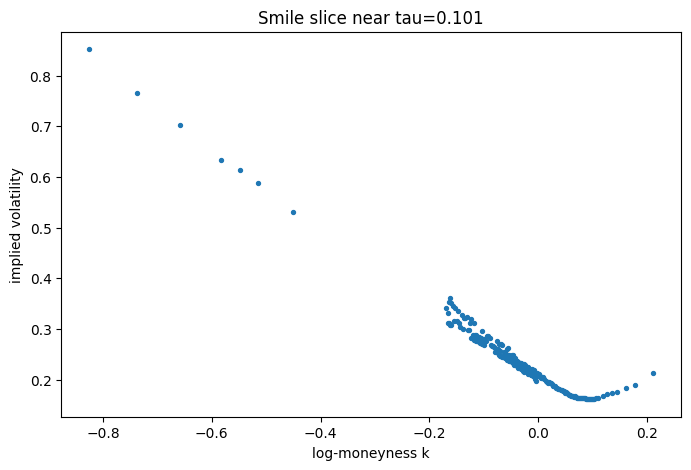

In [17]:
plot_df = subset[["k", "iv"]].dropna().sort_values("k")
plt.figure(figsize=(8, 5))
plt.scatter(plot_df["k"], plot_df["iv"], s=8)
plt.xlabel("log-moneyness k")
plt.ylabel("implied volatility")
plt.title(f"Smile slice near tau={tau_target:.3f}")
plt.show()

## Validate the whole cleaned data

In [18]:
processed_data_path = Path.cwd().parent / "data" / "processed" / "processed.parquet"
df = pd.read_parquet(processed_data_path)

In [19]:
print(df["quote_date"].min(), df["quote_date"].max())
print(df["option_type"].value_counts())
print(df[["tau", "iv", "k"]].describe())

2019-01-02 00:00:00 2023-12-29 00:00:00
option_type
put     7848582
call    7561341
Name: count, dtype: int64
                tau            iv             k
count  1.540992e+07  1.540992e+07  1.540992e+07
mean   3.330657e-01  2.964374e-01 -1.125891e-01
std    5.238231e-01  2.386220e-01  2.871778e-01
min    2.739726e-03  1.008000e-02 -3.870278e+00
25%    5.479452e-02  1.752900e-01 -1.780906e-01
50%    1.397260e-01  2.382100e-01 -5.504882e-02
75%    3.972603e-01  3.252000e-01  2.199913e-02
max    6.024658e+00  3.000000e+00  1.154376e+00


In [20]:
sample_date = df["quote_date"].dropna().sort_values().iloc[0]

surface_df = df.loc[df["quote_date"] == sample_date].copy()

In [21]:
plot_df = surface_df.copy()
plot_df = plot_df[
    (plot_df["tau"] > 7 / 365)
    & (plot_df["tau"] < 3.0)
    & (plot_df["iv"] > 0.01)
    & (plot_df["iv"] < 3.0)
    & (plot_df["rel_spread"] < 0.5)
].copy()

plot_df.shape

(8067, 26)

In [22]:
plot_df_call = plot_df[plot_df["option_type"] == "call"].copy()
plot_df_put = plot_df[plot_df["option_type"] == "put"].copy()

In [23]:
k = np.linspace(plot_df["k"].min(), plot_df["k"].max(), 60)
tau = np.linspace(plot_df["tau"].min(), plot_df["tau"].max(), 50)

KGRID, TAUGRID = np.meshgrid(k, tau, indexing="ij")

In [24]:
points = plot_df[["k", "tau"]].to_numpy()
values = plot_df["iv"].to_numpy()

Z = griddata(points, values, (KGRID, TAUGRID), method="linear")

Z_nearest = griddata(points, values, (KGRID, TAUGRID), method="nearest")
Z = np.where(np.isnan(Z), Z_nearest, Z)

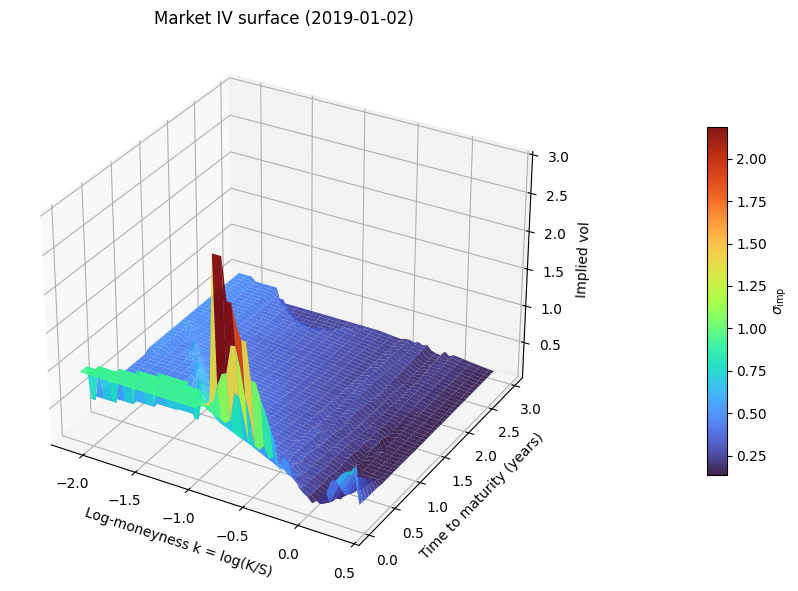

In [25]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(KGRID, TAUGRID, Z, cmap="turbo", edgecolor="none", alpha=0.92)

ax.set_xlabel("Log-moneyness k = log(K/S)")
ax.set_ylabel("Time to maturity (years)")
ax.set_zlabel("Implied vol")
ax.set_title(f"Market IV surface ({sample_date.date()})")

plt.tight_layout(rect=[0, 0, 0.88, 1])
cax = fig.add_axes([0.91, 0.2, 0.022, 0.58])
fig.colorbar(surf, cax=cax, label=r"$\sigma_{\mathrm{imp}}$")
plt.show()

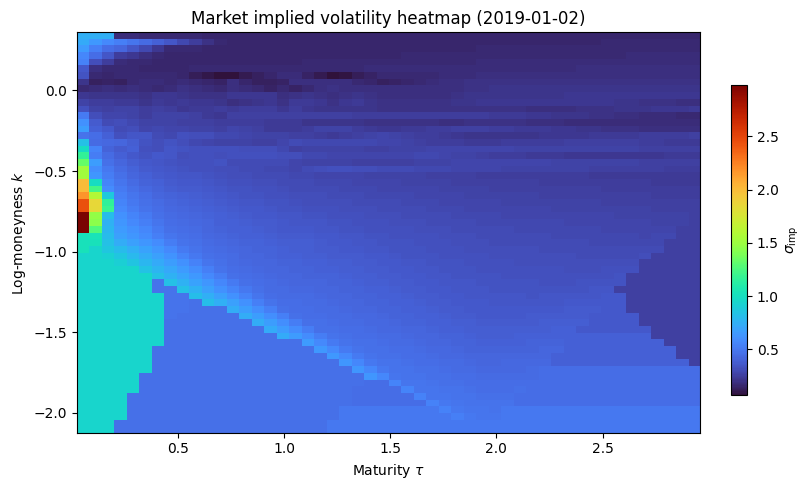

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(
    Z,
    origin="lower",
    aspect="auto",
    extent=[tau.min(), tau.max(), k.min(), k.max()],
    cmap="turbo",
)

ax.set_xlabel("Maturity $\\tau$")
ax.set_ylabel("Log-moneyness $k$")
ax.set_title(f"Market implied volatility heatmap ({sample_date.date()})")

plt.tight_layout(rect=[0, 0, 0.9, 1])
cax = fig.add_axes([0.92, 0.2, 0.02, 0.62])
fig.colorbar(im, cax=cax, label="$\\sigma_{\\mathrm{imp}}$")
plt.show()

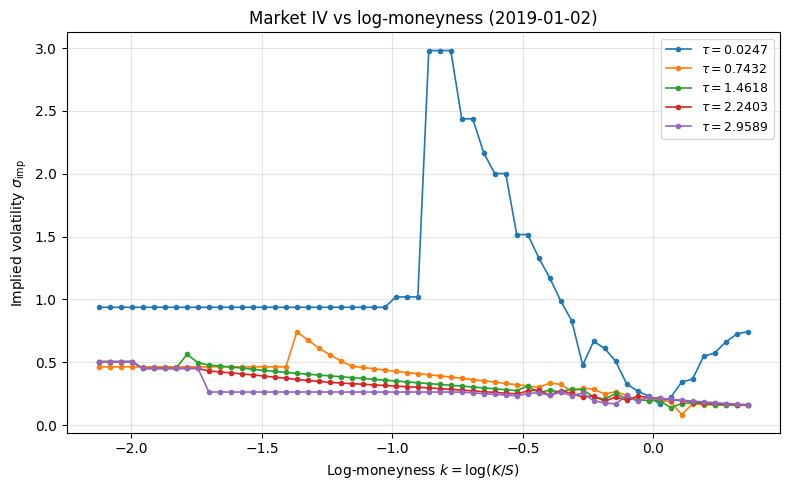

In [27]:
num_sections = 5
j_idx = [round(i * (len(tau) - 1) / (num_sections - 1)) for i in range(num_sections)]

fig, ax = plt.subplots(figsize=(8, 5))
for j in j_idx:
    ax.plot(k, Z[:, j], marker="o", ms=3, lw=1.2, label=rf"$\tau={tau[j]:.4f}$")

ax.set_xlabel(r"Log-moneyness $k = \log(K/S)$")
ax.set_ylabel(r"Implied volatility $\sigma_{\mathrm{imp}}$")
ax.set_title(f"Market IV vs log-moneyness ({sample_date.date()})")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()